# Tarea Semanal 2
<div style="text-align: center;">
  <img src="images/logo_utnba.png" width="400">
</div>


## punto 1: 

Establezca la funcion transferencia pasa bajos $T_{LPF}(s)$ mediante aproximacion de maxima planicidad, por caso, Butterwoth de orden 6.

Para este caso primeramente se obtiene los Q que se necesita para realizar este pasa bajos de orden 6, por lo que se realiza en 3 etapas donde cada etapa es un filtro de orden 2 teniendo un Q distinto para cada etapa.

El Q de un filtro de orden 2 se obtiene de la siguiente manera: $Q=\frac{1}{2cos(\phi)}$

Para obtener los distintos $\phi$ se obtiene de la siguiente manera, como mi filtro es de orden 6, es decir par, se usa la siguiente formula para obtener los distintos $\phi$

$$\phi=\frac{k\pi}{n} + \frac{\pi}{2n}$$

$$n=6 \Rightarrow \phi=\frac{k\pi}{6} + \frac{\pi}{12}$$

Entonces se puede obtener hasta 12 valores de $\phi$ distintos, pero solo nos sirven 3 ya que 6 son complejos conjugados y de los 6 3 estan en el semiplano derecho y 3 en el semiplano izquierdo, y debido a que si elijo los 3 de la derecha mi sistema seria causal, por lo que se elije los 3 del semiplano izquierdo.

De esta manera se obtienen los siguientes valores de $\phi$

$$\phi_1=\frac{\pi}{12},    \phi_2=\frac{3\pi}{12},     \phi_3=\frac{5\pi}{12}$$

Una vez obtenido todos los $\phi$ se obtener los Q para diseñar nuestro filtro butterwoth de orden 6.

$$Q_1=\frac{1}{2cos(\frac{\pi}{12})} \Rightarrow Q_1=0.518$$

$$Q_2=\frac{1}{2cos(\frac{3\pi}{12})} \Rightarrow Q_2=0.707$$

$$Q_3=\frac{1}{2cos(\frac{5\pi}{12})} \Rightarrow Q_3=1.932$$

Una vez obtenido los distintos Q necesarios para realizar el butterwoth de orden 6 implemento cada Q en un filtro pasa bajos de orden 2.

![Circuito RLC](images/punto_1/circuitoRLC.png)

Al resolver el filtro se obtiene lo siguiente:

$$T(s) = \frac{\frac{1}{LC}}{S^2 + S\frac{R}{L} + \frac{1}{LC}}$$

Si lo normalizo a W=1 y impedancia igual a uno R=1

$$T(s) = \frac{1}{S^2 + S \frac{1}{Q} + 1} \Rightarrow siendo L=Q, C=\frac{1}{L}=\frac{1}{Q}$$

Quedando de la siguiente manera, para las 3 etapas.

![Circuito RLC](images/punto_1/circuitoRLC_butterwoth.png)

Bueno y realizando los calculos se obtienen los siguientes valores

$$Q_1 = 0.518 \Rightarrow L=0.518, C=1.931$$

$$Q_1 = 0.707 \Rightarrow L=0.707, C=1.414$$

$$Q_1 = 0.518 \Rightarrow L=1.932, C=0.518$$


## punto 2

Obtenga respuesta de modulo, fase y diagramas de polos y ceros de forma cualitativa.


Diagrama de polos y ceros del butterwoth

![Circuito RLC](images/punto_1/butterwoth_polosCeros.png)

Para la respuesta de modulo se puede realizar primeramente en la primera etapa como una aproximacion para ver como quedaria.

Una vez teniendo en cuenta como es la respuesta en modulo de un RLC y teniendo en cuenta que para mi butterwoth se usa 3 RLC en cascada, se puede decir que la respuesta en modulo es como que se si se sumaran.

Dicho de otra manera por ejemplo la primera etapa me da una respuesta que cae a -40db/dec y como las 3 etapas tienen la misma configuracion entonces cada etapa aporta -40db/dec, entonces al tener la salida completa lo que se obtiene es una caida de -120 db/dec debido a las 3 etapas de mi filtro, y ademas la frecuencia de corte cae a -3db en su wc, que en mi caso seria a wc=1.

![Circuito RLC](images/punto_1/circuitoRLC_modulo.png)

![Circuito RLC](images/punto_1/circuitoRLC_moduloTotal.png)

Para la respuesta de fase ocurre lo mismo, se analiza primeramente para la primera etapa y se observa como es que funciona, y se observa que este mete un defasaje de -180°, entonces se puede concluir que cada etapa influye un dejasaje de -180° y entonces se puede decir que el defasaje que me da en total es de -180°*3 que es de 540°.

Todo esto es teoricamente

![Circuito RLC](images/punto_1/circuitoRLC_fase.png)

![Circuito RLC](images/punto_1/circuitoRLC_faseTotal.png)

## punto 3

Implemente una red normalizada que responda a $T_{LPF}(s)$ mediante secciones de segundo orden (SOS) separadas por buffers. En orden creciente de Q (Q1 < Q2 < Q3).

SOS_1: Sallen-key ---- SOS_2: KHN ---- SOS_3: MFB



### SOS_1: Sallen-key

<div style="text-align: center;">
  <img src="images/sallenKey_circuitoLPF.png" width="400">
</div>

$$V_y = V_o \frac{R_3}{R_3+R_4} \Rightarrow V_y=V_o \frac{1}{1 + \frac{R_4}{R_3}}$$

$$\frac{V_x - V_y}{R_2}=\frac{V_y}{\frac{1}{SC_2}} \Rightarrow \frac{V_x}{R_2}=V_ySC_2+\frac{V_y}{R_2} \Rightarrow V_x = V_y(SC_2+\frac{1}{R_2})R_2$$

Se obtiene la siguiente transferencia.

$$T(s) = \frac{\frac{K+1}{R_1R_2C_1C_2}}{S^2 + S[\frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_2}) - \frac{K}{R_2C_1}] + \frac{1}{R_1R_2C_1C_2}}$$

$$K=\frac{R_4}{R_3}, w_o = \frac{1}{\sqrt{(R_1R_2C_1C_2)}}$$

Entonces se puede observar primeramente que la ganacia siempre sera mas que 1, por lo que para obtener una ganacia de 0db en mi banda de paso yo defino como un criterio que mi K sea lo menor posible, de tal manera que gane 0db en mi banda de paso.

Tambien para realizar calculos mas sencillos lo normalizo en frecuencia, es decir que tomo w=1, tambien lo normalizo en impedancia considerando todas mis resistencias igual a 1.

Criterio $K=0.01 = \frac{1}{100}$, $R_n = 1$ y $w_o=1$

$$w_o^2=\frac{1}{R_1R_2C_1C_2} \Rightarrow 1=\frac{1}{C_1C_2} \Rightarrow 1 = C_1C_2 \Rightarrow \boxed{C_1=\frac{1}{C_2}}$$

$$\frac{w_o}{Q} = \frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_2}) - \frac{K}{R_2C_1}$$

$$\frac{1}{Q} = \frac{1}{C_2}(1 + 1) - \frac{K}{C_1} $$

$$\frac{1}{Q} = \frac{2}{C_2} - KC_2$$

operando un poco la ecuacion se llega a la siguiente expresion.

$$\boxed{C_2 = \frac{1}{2KQ}(\sqrt{1+8KQ^2}-1)}$$

Una vez obtenido $C_1$ y $C_2$ en funcion de Q, puedo sacar los valores con mi Q y mi K deseados, $Q=0.518$ y $K=\frac{1}{100}$

$$\boxed{C_2 = 0.747} ---- \boxed{C_1=1.339}$$

### SOS_2: KHN

![Circuito KHN](images/KHN_circuitoLPF.png)

Operando se obtiene la siguiente transferencia:

$$T(s) = \frac{\frac{R_3}{C_1C_2R_4R_5R_1}}{S^2 + S\frac{R_3}{C_1R_4(K+1)}(\frac{1}{R_1}+\frac{1}{R_2}+\frac{1}{R_3}) + \frac{R_3}{C_1C_2R_4R_5R_2}} ---> con ---> K = \frac{R_6}{R_7}$$

$$w_o^2=\frac{R_3}{C_1C_2R_4R_5R_2}$$

$$\frac{w_o}{Q} = \frac{R_3}{C_1R_4(K+1)}(\frac{1}{R_1}+\frac{1}{R_2}+\frac{1}{R_3})$$

Del mismo modo que en el primero SOS_1 normalizo en frecuencia en impedancia de manera que $R_n=1$ y mi $w_o = 1$ quedandome de la siguiente manera

$$T(s)$$

$$1=\frac{1}{C_1C_2} \Rightarrow C_2=\frac{1}{C_1}$$

$$\frac{1}{Q} = \frac{1}{C_1(1+1)}(1+1+1) \Rightarrow \frac{1}{Q} = \frac{3}{2C_1} \Rightarrow \boxed{C_1=\frac{3Q}{2}}$$

$$\boxed{C_2=\frac{2}{3Q}}$$

Una vez obtenido las expresiones, se calcula a partir de mi $Q=0.707$ los distintos C

$$\boxed{C_1=1.061}---\boxed{C_2=0.943}$$

### SOS_3: MFB

![Circuito MFB](images/MFB_circuitoLPF.png)

$$T(s) = \frac{\frac{-1}{R_1R_3C_2C_5}}{S^2 + S\frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_3} + \frac{1}{R_4}) + \frac{1}{R_3R_4C_2C_5}}$$

$$I: w_o^2 = \frac{1}{R_3R_4C_2C_5}$$

$$II:\frac{wo}{Q} = \frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_3} + \frac{1}{R_4})$$

De la misma manera que hize con los anteriores, lo normalizo para obtener una $w_o=1$ y mis resistencias igual a 1 $R_n = 1$ teniendo de esta manera la sigiente transformada.

$$T(s) = \frac{1}{1}$$

$$1 = \frac{1}{C_2C_5}$$

$$\frac{1}{Q} = \frac{1}{C_2}(1+1+1) \Rightarrow \frac{1}{Q} = \frac{3}{C_2} \Rightarrow \boxed{C_2 = 3Q}$$

$$C_5 = \frac{1}{C_2} \Rightarrow \boxed{C_5 = \frac{1}{3Q}}$$

Ahora calculando los valores de $C_2$ y $C_5$ para mi $Q=1.932$ tengo los siguientes valores

$$\boxed{C_2=5.796} --- \boxed{C_5=0.173}$$

## punto 4

Indique las normas de frecuencia $\Omega_{\omega}$ e impedancia $\Omega_Z$ adoptadas y los ajustes necesarios para obtener una ganancia de 10 dB en la banda de paso.


Las normas de frecuencia e impedancia adoptadas seran como las de mis ejemplos anterios, es decir adopto una impedancia de 1, es decir que tomo todas mis resistencias = 1 $R_n=1$ y tomo mi frecuencia de corte en uno, es decir, $w_o=1$.

Luego para obtener una ganancia de 10db en la banda de paso, lo hago en la ultima etapa en el MFB

Entonces como se requiere una ganancia de 10db se comienza por ese paso:

$$G_{dB} = 10 \Rightarrow G_{dB} = 20 log_{10}(G) \Rightarrow G = 10^{\frac{G_{dB}}{10}}$$

$$G_{dB} = 10 \Rightarrow \boxed{ G= 3.162}$$

Entonces al tener la ganancia que debe de tener en veces ahora se trabaja en la ganancia del circuito por lo que se analiza en la funcion transferencia de mi SOS3 MFB

$$T(s) = \frac{\frac{-1}{R_1R_3C_2C_5}}{S^2 + S\frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_3} + \frac{1}{R_4}) + \frac{1}{R_3R_4C_2C_5}}$$

analizo para H(0)

$$H(0) = \frac{R_4}{R_1}$$

Entonces teniendo esa relacion de ganancia para H(0) y queriendo que gane 3.162 entonces aplico lo siguiente:

$$H(0) = G = 3.162 = \frac{R_4}{R_1} \Rightarrow \boxed{R_4 = 3.162 R_1}$$

Tomo como referencia resesistencias comerciales que me den mas o menos cerca esa relacion, con lo cual obtengo lo siguiente:

$$\boxed{R_1 = 3.3 K\ohm --- R_4 = 10 K\ohm} \Rightarrow R_4 = 3.3k\ohm * 3.162 = 10.44 K\ohm$$ 

estan cerca de lo acordado

y Como hize de costumbre realizo lo de siempre que es normalizar con $w_o=1$ y mis $R_3=1$

$$I:  w_o^2 = \frac{1}{R_3R_4C_2C_5}$$

$$II: \frac{w_o}{Q} = \frac{1}{C_2}(\frac{1}{R_1} + \frac{1}{R_3} + \frac{1}{R_4})$$

y reemplazando mi $w_o = 1$ y mis resistencias con los valores acordados se obtiene lo siguiente.

$$R_1=3.3 K\ohm --- R_4 = 10 k\ohm --- C_2 = 1.933 --- C_5 = 5.173*10^{-5} --- R_3=1$$

## punto 5

Verifique los resultados obtenidos analiticamente mediante simulaciones numericas y/o simbolicas en python y circuitales LTSpice

### simulaciones en ltSpice.

#### simulaciones con la primera red circuital


![Circuito RLC](images/ltspice/butterwothRLC_circuito.png)

Respuesta en frecuencia:

![Circuito RLC](images/ltspice/butterwothRLC_grafico.png)

Frecuencia de corte:

![Circuito RLC](images/ltspice/butterwothRLC_fc.png)

#### simulaciones con SK-KHN-MFB

##### simulaciones SK

Circuito simulado

![Circuito RLC](images/ltspice/SOS1SK_circuito.png)

Ganancia

![Circuito RLC](images/ltspice/SOS1SK_grafico.png)

frecuencia de corte

![Circuito RLC](images/ltspice/SOS1SK_fc.png)

##### simulaciones KHN

Circuito simulado

![Circuito RLC](images/ltspice/SOS2KHN_circuito.png)

Ganancia

![Circuito RLC](images/ltspice/SOS2KHN_grafico.png)

frecuencia de corte

![Circuito RLC](images/ltspice/SOS2KHN_fc.png)

##### simulaciones MFB

Circuito simulado

![Circuito RLC](images/ltspice/SOS3MFB_circuito.png)

Ganancia

![Circuito RLC](images/ltspice/SOS3MFB_grafico.png)

frecuencia de corte

![Circuito RLC](images/ltspice/SOS3MFB_fc.png)

### simulacion Butterwoth orden 6 SK-KHN-MFB

Circuito simulado

![Circuito RLC](images/ltspice/butterwothSKKHNMFB_circuito.png)

Ganancia

![Circuito RLC](images/ltspice/butterwothSKKHNMFB_grafico.png)

Frecuencia de corte

![Circuito RLC](images/ltspice/butterwothSKKHNMFB_fc.png)


### simulacion Butterwoth orden 6 SK-KHN-MFB con 10 db de ganancia

Circuito simulado

![Circuito RLC](images/ltspice/butterwothSKKHNMFB_circuitoG10.png)

Ganancia

![Circuito RLC](images/ltspice/butterwothSKKHNMFB_graficoG10.png)


### Simulacion en python del filtro butterwoth de orden 6

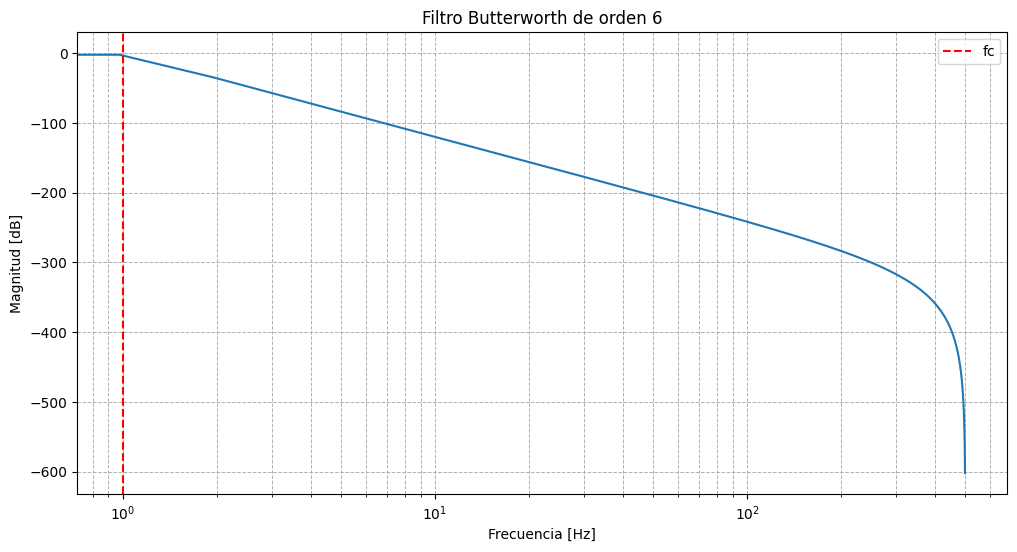

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp

orden = 6
fc = 1/(2*np.pi)
fc = 1
fs = 1000

b, a = sp.butter(orden, fc/(fs/2), btype='low')

w, h = sp.freqz(b, a)

plt.figure(figsize=(12,6))
plt.semilogx((w*fs)/(2*np.pi), 20*np.log10(abs(h)))
plt.title("Filtro Butterworth de orden 6")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid(which='both', linestyle='--', linewidth=0.7)
plt.axvline(fc, color='red', linestyle='--', label='fc')
plt.legend()
plt.show()